In [102]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

## Scene Model

In [325]:
## Configuration
w, h = 128, 128              # screen size
camera = np.array([0, 0, -5.0])  # camera position

In [326]:
class Sphere():
    def __init__(self, center, color, r):
        self.c = np.asarray(center)
        self.color = np.asarray(color)
        self.r = r

    # adapted from jamesbowman/raytrace
    def intersect(self, origin, direction):
        b = 2 * np.dot(direction, (origin - self.c))
        c1 = self.c @ self.c
        c2 = origin @ origin
        c3 = self.c @ origin
        c4 = self.r * self.r
        c = c1 + c2 - 2 * c3 - c4
        disc = b * b - 4 * c
        sq = np.sqrt(np.maximum(0, disc))
        h0 = (-b - sq) / 2
        h1 = (-b + sq) / 2
        h = np.where((h0 > 0) & (h0 < h1), h0, h1)
        pred = (disc > 0) & (h > 0)
        return np.where(pred, h, np.inf)

In [327]:
## Scene definition
RED=np.array([1.0, 0.0, 0.0])
GREEN=np.array([0.0, 1.0, 0.0])
BLUE=np.array([0.0, 0.0, 1.0])

scene = [Sphere([0.0, 0.0, 5.0],   RED,   0.6),
         Sphere([1.0, -1.0, 6.0], GREEN, 1.0),
         Sphere([-1.0, 1.0, 6.0], BLUE, 0.5)]

In [355]:
## Rendering
def raytrace(origin, direction, scene):
    distances = np.array([s.intersect(origin, direction) for s in scene])
    nearest = np.min(distances, axis=0)
    color = np.zeros((direction.shape[0], 3))  # R=0 G=0 B=0
    for (s, d) in zip(scene, distances):
        hit = (nearest != np.inf) & (d == nearest)
        color[hit] = s.color
    return color

r = float(w) / h
screen = (-1, 1 / r + .25, 1, -1 / r + .25)
x = np.tile(np.linspace(screen[0], screen[2], w), h)
y = np.repeat(np.linspace(screen[1], screen[3], h), w)
q = np.hstack((x.reshape(-1, 1), y.reshape(-1, 1), np.ones((x.shape[0], 1))))

images = np.empty((4, w, h, 3))
c = np.copy(camera)
for i in range(images.shape[0]):
    direction = q - c
    direction = direction / np.linalg.norm(direction, axis=1, keepdims=True)
    images[i] = raytrace(c, direction, scene).reshape(w, h, 3)
    c += np.array([0.0, 0.0, -2.0])
print(camera)

[ 0.   0.  -3.4]


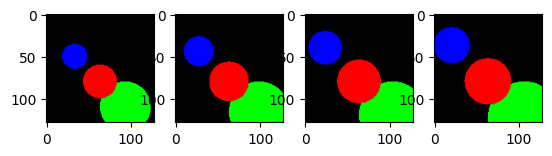

In [356]:
fig, ax = plt.subplots(1, images.shape[0])
for i in range(ax.shape[0]):
    ax[i].imshow(images[i].reshape(w, h, 3))